# Training Analysis and Visualization Dashboard

### TLDR
This notebook compiles validation visualizations for model performance, currently focusing on the Resnet model trained on the Galaxy dataset.

### Objective
Conduct a comprehensive analysis of training dynamics and mask evolution for the Resnet architecture.

### Description
* **Data Selection**: Loads data for a specifically chosen epoch alongside complete training metrics and logs.
* **Trend Analysis**: Generates evolution curves for losses, accuracy, and regularization terms.
* **Performance Verification**: Verifies key performance indicators (accuracy, F1, recall, precision) for the selected epoch.
* **Error Analysis**: Renders the confusion matrix.
* **Feature Selection**: Visualizes the feature selection mask's evolution through both static views and animations.

### Results
* **Mask Evolution**: The mask demonstrates expected evolutionary behavior.
* **Classification Performance**: The selected epoch (150) exhibits strong classification performance despite significant pixel deselection.
* **Pending**: (TODO: quantify exact mask loss).


In [12]:
# Importing functions and methods.
import sys
import os

current_dir = os.getcwd() 
utils_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'utils'))
models_path = os.path.abspath(os.path.join(current_dir, '..', '..', 'src', 'models'))
notebook_utils = os.path.abspath(os.path.join(current_dir, '..'))

if utils_path not in sys.path: sys.path.append(utils_path)
if models_path not in sys.path: sys.path.append(models_path)
if notebook_utils not in sys.path: sys.path.append(notebook_utils)

print(f"Adicionado ao PATH: {utils_path}")
print(f"Adicionado ao PATH: {models_path}")
print(f"Adicionado ao PATH: {notebook_utils}")

# 2. Third-party Library Imports (Data, Math, ML)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms

# 3. Visualization Imports
import matplotlib.pyplot as plt
import matplotlib as mlp
import seaborn as sns
import pandas as pd

# 4. Local/Project Imports (Custom Modules)
from StaticMaskTraining import StaticMaskTraining
import NotebookUtils as nu
import ModelTester as mt
import DatasetsDict as dd

Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/utils
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/src/models
Adicionado ao PATH: /home/andre-marques/Desktop/Estudo/PowerRangersCode/notebooks


In [13]:
# SETTING GLOBAL VARIABLES
var_root_dir = "../../checkpoints/"
var_global_checkpoint_masked = "galaxy10_lenet_masked"
var_global_checkpoint_unmasked = "galaxy10_lenet_unmasked"

# Setting the class helper
utils = nu.NotebookUtils()

In [14]:
def rebuild_training_log(training_id, root_dir="../../checkpoints/"):
    data_list = []
    i = 1
    eps = 1e-9 

    print(f"🔄 Reconstruindo log para: {training_id}")

    while True:
        path = os.path.abspath(os.path.join(root_dir, training_id, f'checkpoint_epoch_{i}.pt'))
        
        if not os.path.exists(path):
            break
            
        try:
            # Carregando com weights_only=False por causa da CM (numpy)
            ckpt = torch.load(path, map_location='cpu', weights_only=False)
            
            cm = np.array(ckpt['cm'])
            
            # --- CÁLCULOS ---
            tp = np.diag(cm)
            fp = np.sum(cm, axis=0) - tp
            fn = np.sum(cm, axis=1) - tp
            
            # Precisão e Recall por classe
            p_class = tp / (tp + fp + eps)
            r_class = tp / (tp + fn + eps)
            f1_class = 2 * (p_class * r_class) / (p_class + r_class + eps)
            
            # Médias Macro em %
            val_precision = np.mean(p_class) * 100
            val_recall = np.mean(r_class) * 100
            val_f1 = np.mean(f1_class) * 100
            
            # Acurácia (pode usar a do ckpt ou recalcular para garantir)
            val_acc = (np.sum(tp) / np.sum(cm)) * 100

            data_list.append({
                'epoch': i,
                'val_accuracy': val_acc,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'val_f1_score': val_f1
            })
            
        except Exception as e:
            print(f"⚠️ Erro na época {i}: {e}")
            break
        i += 1

    df_rebuilt = pd.DataFrame(data_list)
    
    # Salva o CSV para você nunca mais passar por isso nesse treino kkk
    save_path = os.path.join(root_dir, training_id, "training_log_reconstructed.csv")
    df_rebuilt.to_csv(save_path, index=False)
    print(f"✅ Log reconstruído e salvo em: {save_path}")
    
    return df_rebuilt

In [15]:
df_masked = rebuild_training_log(var_global_checkpoint_masked, var_root_dir)
df_unmasked = rebuild_training_log(var_global_checkpoint_unmasked, var_root_dir)

🔄 Reconstruindo log para: galaxy10_lenet_masked


✅ Log reconstruído e salvo em: ../../checkpoints/galaxy10_lenet_masked/training_log_reconstructed.csv
🔄 Reconstruindo log para: galaxy10_lenet_unmasked
✅ Log reconstruído e salvo em: ../../checkpoints/galaxy10_lenet_unmasked/training_log_reconstructed.csv


In [16]:
# Visualization

print(df_masked.head())
print(df_unmasked.head())

   epoch  val_accuracy  val_precision  val_recall  val_f1_score
0      1     27.819549      20.463515   21.148257     18.077658
1      2     30.137845      21.930080   25.125506     22.323921
2      3     30.263158      22.989423   24.135452     21.000921
3      4     31.140351      29.821117   26.230730     24.285743
4      5     34.899749      33.650541   29.985652     28.280773
   epoch  val_accuracy  val_precision  val_recall  val_f1_score
0      1     29.699248      24.997261   23.087454     21.103079
1      2     32.393484      30.953005   26.974446     25.514511
2      3     33.395990      32.227258   26.226913     23.633542
3      4     36.779449      33.932801   31.594148     30.123732
4      5     34.273183      29.299293   31.445742     28.499233


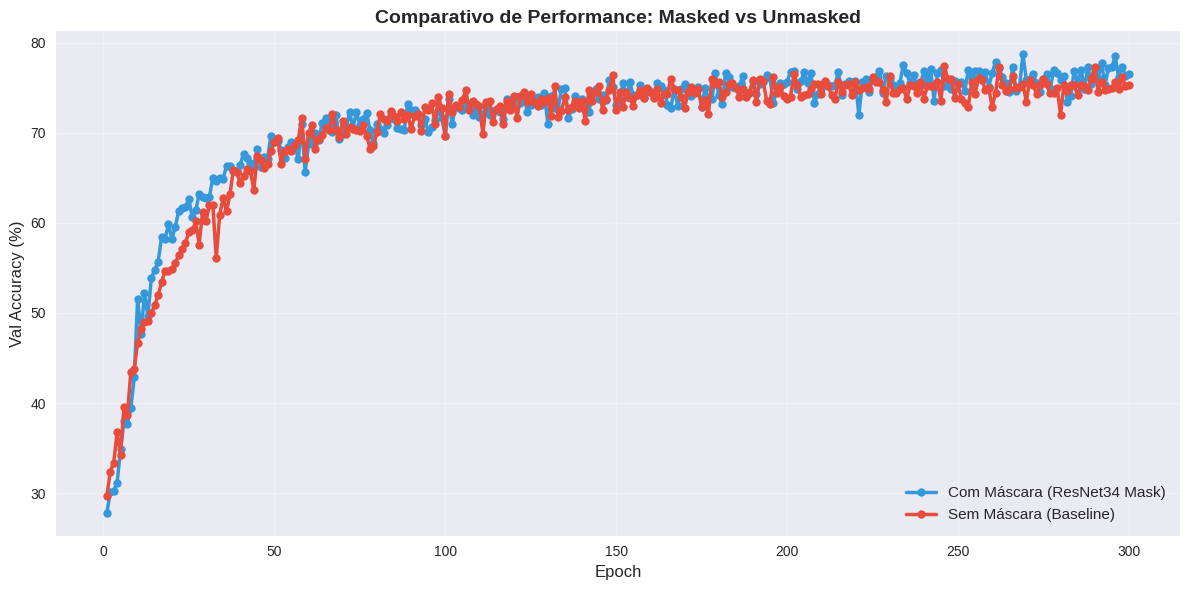


🏆 MASKED MODEL (Top 10)
época      | métrica   
-----------------------
269        |      78.70%
296        |      78.51%
261        |      77.88%
292        |      77.76%
234        |      77.51%
266        |      77.32%
288        |      77.32%
298        |      77.32%
295        |      77.26%
294        |      77.19%

🏆 UNMASKED MODEL (Top 10)
época      | métrica   
-----------------------
246        |      77.38%
262        |      77.32%
290        |      77.32%
202        |      76.50%
149        |      76.38%
266        |      76.32%
230        |      76.25%
298        |      76.19%
225        |      76.13%
196        |      76.13%

⭐ Melhor época Masked: 269
⭐ Melhor época Unmasked: 246


In [17]:
# Configuração do Estilo
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))

# Define qual métrica plotar (pode trocar para val_f1_score se preferir)
METRIC_NAME = "val_accuracy" 

# --- PLOTAGEM ---
# Modelo COM Máscara (Azul)
ax.plot(df_masked.epoch, df_masked[METRIC_NAME], 'o-', 
        color='#3498db', linewidth=2.5, markersize=6, label='Com Máscara (ResNet34 Mask)')

# Modelo SEM Máscara (Vermelho)
ax.plot(df_unmasked.epoch, df_unmasked[METRIC_NAME], 'o-', 
        color='#e74c3c', linewidth=2.5, markersize=6, label='Sem Máscara (Baseline)')

# --- CUSTOMIZAÇÃO ---
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel(f'{METRIC_NAME.replace("_", " ").title()} (%)', fontsize=12)
ax.set_title(f'Comparativo de Performance: Masked vs Unmasked', fontsize=14, fontweight='bold')

ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

# Ordena de forma decrescente pela métrica e pega as 10 primeiras
top_10_masked = df_masked.sort_values(by=METRIC_NAME, ascending=False).head(10)
top_10_unmasked = df_unmasked.sort_values(by=METRIC_NAME, ascending=False).head(10)

# Pega a melhor absoluta para as suas variáveis
best_epoch_masked = top_10_masked.iloc[0]['epoch']
best_epoch_unmasked = top_10_unmasked.iloc[0]['epoch']

best_epoch_masked = int(best_epoch_masked)
best_epoch_unmasked = int(best_epoch_unmasked)


def print_top_epochs(df_top, title):
    print(f"\n🏆 {title} (Top 10)")
    print(f"{'época':<10} | {'métrica':<10}")
    print("-" * 23)
    for _, row in df_top.iterrows():
        # Formata o print conforme solicitado: epoca | metrica
        print(f"{int(row['epoch']):<10} | {row[METRIC_NAME]:>10.2f}%")

# Executa os prints
print_top_epochs(top_10_masked, "MASKED MODEL")
print_top_epochs(top_10_unmasked, "UNMASKED MODEL")

print(f"\n⭐ Melhor época Masked: {best_epoch_masked}")
print(f"⭐ Melhor época Unmasked: {best_epoch_unmasked}")

pegar um modelo bem ruim pra um dataset bem complexo -> o modelo ruim tem q performar mal

máscara para cada tipo de classe -> verificar isso (tem a ver com federate learning, um cliente por classe) -> media para cada tipo de mascara (classe)
-> gerar máscara global com transformação matemática

ir atras de papers que permitem remover a informação -> diminuir dimensionalidade da imagem -> cnn? ViT? 

fazer o protocolo da banda larga

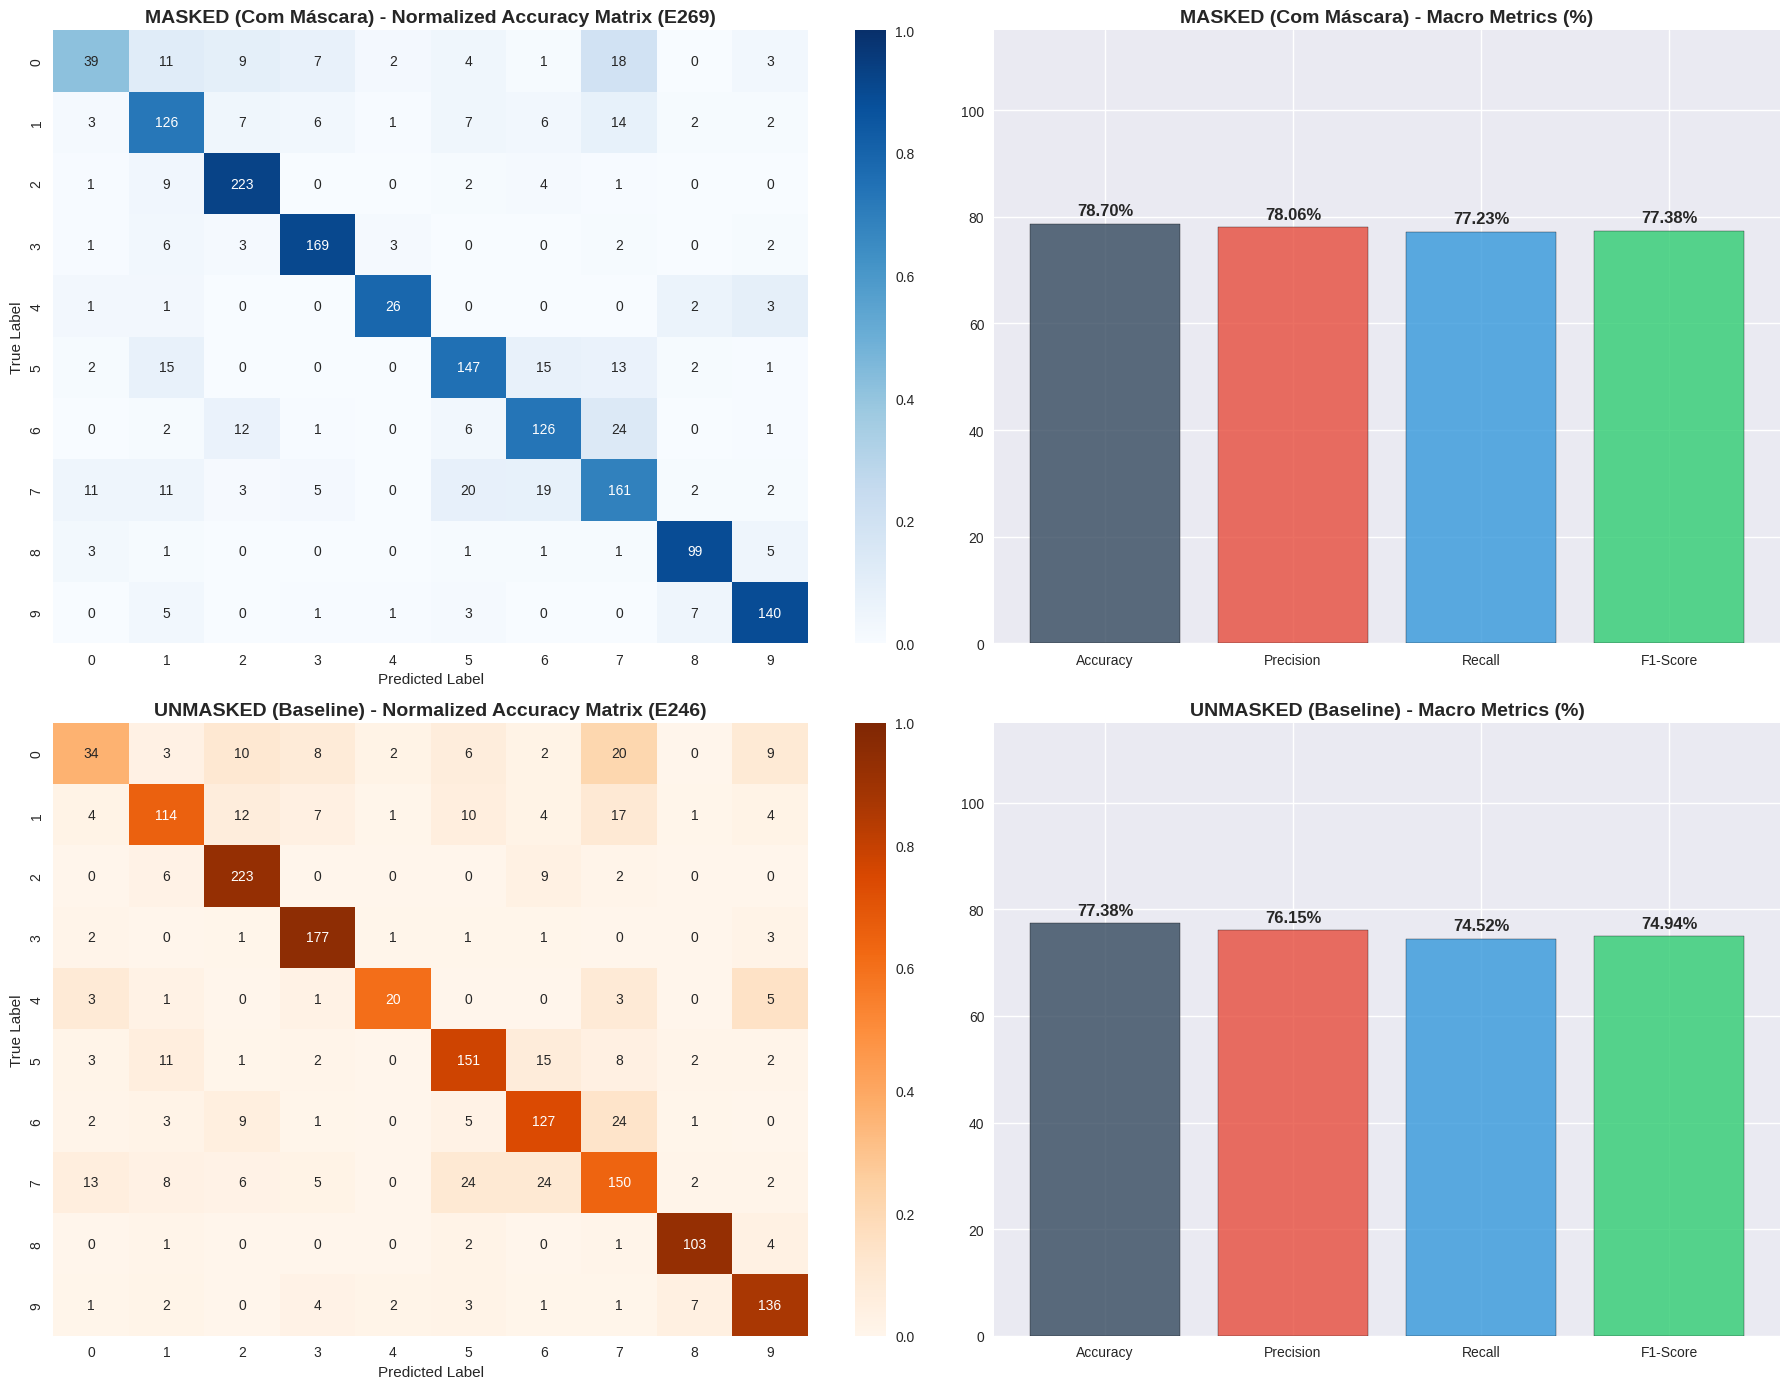


MÉTRICA COMPARATIVA  | MASKED (E269)   | UNMASKED (E246)
-----------------------------------------------------------------
ACCURACY             |          78.70% |            77.38%
PRECISION            |          78.06% |            76.15%
RECALL               |          77.23% |            74.52%
F1_SCORE             |          77.38% |            74.94%


In [18]:
# 1. Setup da Figura (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(18, 14), gridspec_kw={'width_ratios': [1.2, 1]})

models_to_plot = [
    {
        "name": "MASKED (Com Máscara)", 
        "id": var_global_checkpoint_masked, 
        "df": df_masked, 
        "best_epoch": best_epoch_masked, 
        "row": 0,
        "cmap": "Blues"
    },
    {
        "name": "UNMASKED (Baseline)", 
        "id": var_global_checkpoint_unmasked, 
        "df": df_unmasked, 
        "best_epoch": best_epoch_unmasked, 
        "row": 1,
        "cmap": "Oranges"
    }
]

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#34495e', '#e74c3c', '#3498db', '#2ecc71']

for item in models_to_plot:
    row = item["row"]
    current_best_ep = item["best_epoch"]
    
    # --- A. Carregar Dados ---
    checkpoint = utils.load_checkpoint(item["id"], current_best_ep)
    if checkpoint is None:
        continue
        
    cm = checkpoint['cm']
    df_current = item["df"]
    
    # --- B. LEFT SIDE: Confusion Matrix NORMALIZADA ---
    # Normalizamos por linha (True Label) para que a cor represente a % de acerto da classe
    # Adicionamos 1e-9 para evitar divisão por zero em classes vazias
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

    # Plotamos o heatmap usando a matriz normalizada para as CORES, 
    # mas mantemos o 'cm' original (bruto) para as ANOTAÇÕES (números)
    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap=item["cmap"], 
                ax=axes[row, 0], cbar=True, vmin=0, vmax=1)
    
    axes[row, 0].set_title(f'{item["name"]} - Normalized Accuracy Matrix (E{current_best_ep})', fontsize=14, fontweight='bold')
    axes[row, 0].set_xlabel('Predicted Label')
    axes[row, 0].set_ylabel('True Label')

    # --- C. RIGHT SIDE: Metrics Bar Chart ---
    try:
        row_data = df_current[df_current['epoch'] == current_best_ep].iloc[0]
        metrics_values = [
            row_data["val_accuracy"], 
            row_data["val_precision"], 
            row_data["val_recall"], 
            row_data["val_f1_score"]
        ]
    except Exception:
        metrics_values = [0, 0, 0, 0]

    bars = axes[row, 1].bar(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
    axes[row, 1].set_ylim(0, 115) 
    axes[row, 1].set_title(f'{item["name"]} - Macro Metrics (%)', fontsize=14, fontweight='bold')
    
    for bar in bars:
        height = bar.get_height()
        axes[row, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- TABELA COMPARATIVA TEXTUAL ---
print(f"\n{'MÉTRICA COMPARATIVA':<20} | {'MASKED (E' + str(best_epoch_masked) + ')':<15} | {'UNMASKED (E' + str(best_epoch_unmasked) + ')':<15}")
print("-" * 65)
for m in ["val_accuracy", "val_precision", "val_recall", "val_f1_score"]:
    v_m = df_masked[df_masked.epoch == best_epoch_masked][m].values[0]
    v_u = df_unmasked[df_unmasked.epoch == best_epoch_unmasked][m].values[0]
    label = m.replace("val_", "").upper()
    print(f"{label:<20} | {v_m:>14.2f}% | {v_u:>16.2f}%")